In [1]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import scipy
from neuro_data.static_images import data_schemas
from staticnet_analyses import base
from staticnet_invariance import deis_reconfigured as deis_schema, dei_stimulus_reconfigured as dei_stimulus
base = dj.create_virtual_module('base', 'neurostatic_base')
ephys = dj.create_virtual_module('ephys', 'neuropixel_ephys')
test = dj.create_virtual_module('test', 'neuropixel_ephys_test')
anatomy = dj.create_virtual_module('anatomy', 'neuropixel_manual_anatomy')
stimulus = dj.create_virtual_module('stimulus', 'pipeline_stimulus')
neuropixel = dj.create_virtual_module('neuropixel', 'pipeline_neuropixel')
collection = dj.create_virtual_module('collection', 'pipeline_collection')
pupil = dj.create_virtual_module('pupil', 'pipeline_eye')

Connecting zhiwei@at-database.stanford.edu:3306


/src/static-networks/staticnet_analyses/multi_mei.py:1648: UserWarning: Use of this table is deprecated. It is kept only for record keeping purpose
  warnings.warn('Use of this table is deprecated. It is kept only for record keeping purpose')


# Compare 2p and npx cc_abs and cc_max

In [4]:
## get all units from neuropixel
net_hash_e2e = 'net_hash = "8b6fe18fa651ebf452db0fbd77d05a01"'   # original model
net_hash_pretrain = 'net_hash = "ebc0a36a504206eb9ed5a336e5b8a2b1"'   # pretrained 2p core model
# net_hash = 'net_hash = "e67196e0d324cc4a34b5e731dab1e0ed"'   # sensorium model

neuron_e2e = base.Dataset.Unit * base.NewEnsembleEval.Unit & 'group_id = 366' & net_hash_e2e
cc_max, cc_abs_e2e, cc_norm_e2e = neuron_e2e.fetch('cc_max', 'cc_abs', 'cc_norm', order_by='animal_id, session, scan_idx, unit_id')

neuron_pretrain = base.Dataset.Unit * base.NewEnsembleEval.Unit & 'group_id = 366' & net_hash_pretrain
cc_abs_pretrain, cc_norm_pretrain = neuron_pretrain.fetch('cc_abs', 'cc_norm', order_by='animal_id, session, scan_idx, unit_id')


In [9]:
np.median(cc_norm_e2e[npx_idxs])

0.635065

In [10]:
np.median(cc_norm_pretrain[npx_idxs])

0.7311

In [4]:
## get all units from neuropixel
net_hash_e2e = 'net_hash = "8b6fe18fa651ebf452db0fbd77d05a01"'   # original model
net_hash_pretrain = 'net_hash = "ebc0a36a504206eb9ed5a336e5b8a2b1"'   # pretrained 2p core model
# net_hash = 'net_hash = "e67196e0d324cc4a34b5e731dab1e0ed"'   # sensorium model

neuron_e2e = base.Dataset.Unit * base.NewEnsembleEval.Unit & 'group_id = 366' & net_hash_e2e
cc_max, cc_abs_e2e, cc_norm_e2e = neuron_e2e.fetch('cc_max', 'cc_abs', 'cc_norm', order_by='animal_id, session, scan_idx, unit_id')

neuron_pretrain = base.Dataset.Unit * base.NewEnsembleEval.Unit & 'group_id = 366' & net_hash_pretrain
cc_abs_pretrain, cc_norm_pretrain = neuron_pretrain.fetch('cc_abs', 'cc_norm', order_by='animal_id, session, scan_idx, unit_id')

# 2p
groups = [233, 237, 239, 243, 271, 272, 275, 279, 284, 285, 329, 330, 336, 337]
net_hash = ["8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da"]
data_hash = ["7572eed73113c993e7d1b92f83e270b4"]
unique_units = base.UnitRanking.Unit & 'ranking_params = 4' & [{'group_id': i} for i in groups] & [{'net_hash': i} for i in net_hash] & [{'data_hash': i} for i in data_hash]
cc_max_2p, cc_abs_2p, cc_norm_2p = (base.NewEnsembleEval.Unit & 'ssid = 1' & unique_units).fetch('cc_max', 'cc_abs', 'cc_norm')

# cc_max_2p, cc_abs_2p, cc_norm_2p = (base.NewEnsembleEval.Unit & 'ssid = 1' & [{'group_id': g} for g in groups] & \
# 'data_hash = "7572eed73113c993e7d1b92f83e270b4" and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da")').fetch('cc_max', 'cc_abs', 'cc_norm')
# cc_max_2p, cc_abs_2p, cc_norm_2p = (base.NewEnsembleEval.Unit & 'ssid = 1' & (deis_schema.NeuronSetRequest & 'method_id = 3')).fetch('cc_max', 'cc_abs', 'cc_norm')

# exclude super noisy neurons 
twop_idxs = np.where(cc_max_2p >= 0.1)[0]
twop_kept = np.where((cc_norm_2p[twop_idxs] >= 0) & (cc_norm_2p[twop_idxs] <= 1))[0]
npx_idxs = np.where(cc_max >= 0.1)[0]
npx_kept = np.where((cc_norm_pretrain[npx_idxs] >= 0) & (cc_norm_pretrain[npx_idxs] <= 1))[0]

# get quality label
neuron_dic = np.array(neuron_e2e.fetch(as_dict=True, order_by='animal_id, session, scan_idx, unit_id'))
label = np.array([(ephys.CuratedClustering.Unit * ephys.Session & dic).fetch1('cluster_quality_label') for dic in neuron_dic])
good_idx = np.where(label[npx_idxs] == 'good')[0]
mua_idx = np.where(label[npx_idxs] == 'mua')[0]
# good_idx = np.where(label == 'good')[0]
# mua_idx = np.where(label == 'mua')[0]

npx_idxs_single = np.where(cc_max[good_idx] >= 0.1)[0]
npx_kept_single = np.where((cc_norm_pretrain[good_idx][npx_idxs_single] >= 0) & (cc_norm_pretrain[good_idx][npx_idxs_single] <= 1))[0]
npx_idxs_multi = np.where(cc_max[mua_idx] >= 0.1)[0]
npx_kept_multi = np.where((cc_norm_pretrain[mua_idx][npx_idxs_multi] >= 0) & (cc_norm_pretrain[mua_idx][npx_idxs_multi] <= 1))[0]


In [5]:
len(label)

364

In [6]:
print(100 - npx_idxs_single.shape[0] / len(cc_max[good_idx])*100)
print(100 - npx_kept_single.shape[0] / len(npx_idxs_single)*100)
print(100 - npx_idxs_multi.shape[0] / len(cc_max[mua_idx])*100)
print(100 - npx_kept_multi.shape[0] / len(npx_idxs_multi)*100)
print(100 - twop_idxs.shape[0] / len(cc_max_2p)*100)
print(100 - twop_kept.shape[0] / len(twop_idxs)*100)

7.647058823529406
4.458598726114644
4.624277456647391
6.060606060606062
0.18686599038974805
1.1708418769130162


In [8]:
scipy.stats.wilcoxon(cc_norm_e2e[npx_idxs], cc_norm_pretrain[npx_idxs])

WilcoxonResult(statistic=10762.0, pvalue=2.0921815925958267e-24)

In [8]:
scipy.stats.wilcoxon(cc_norm_e2e[npx_idxs], cc_norm_pretrain[npx_idxs])

WilcoxonResult(statistic=10762.0, pvalue=2.0921815925958267e-24)

In [38]:
cc_norm_e2e.shape

(364,)

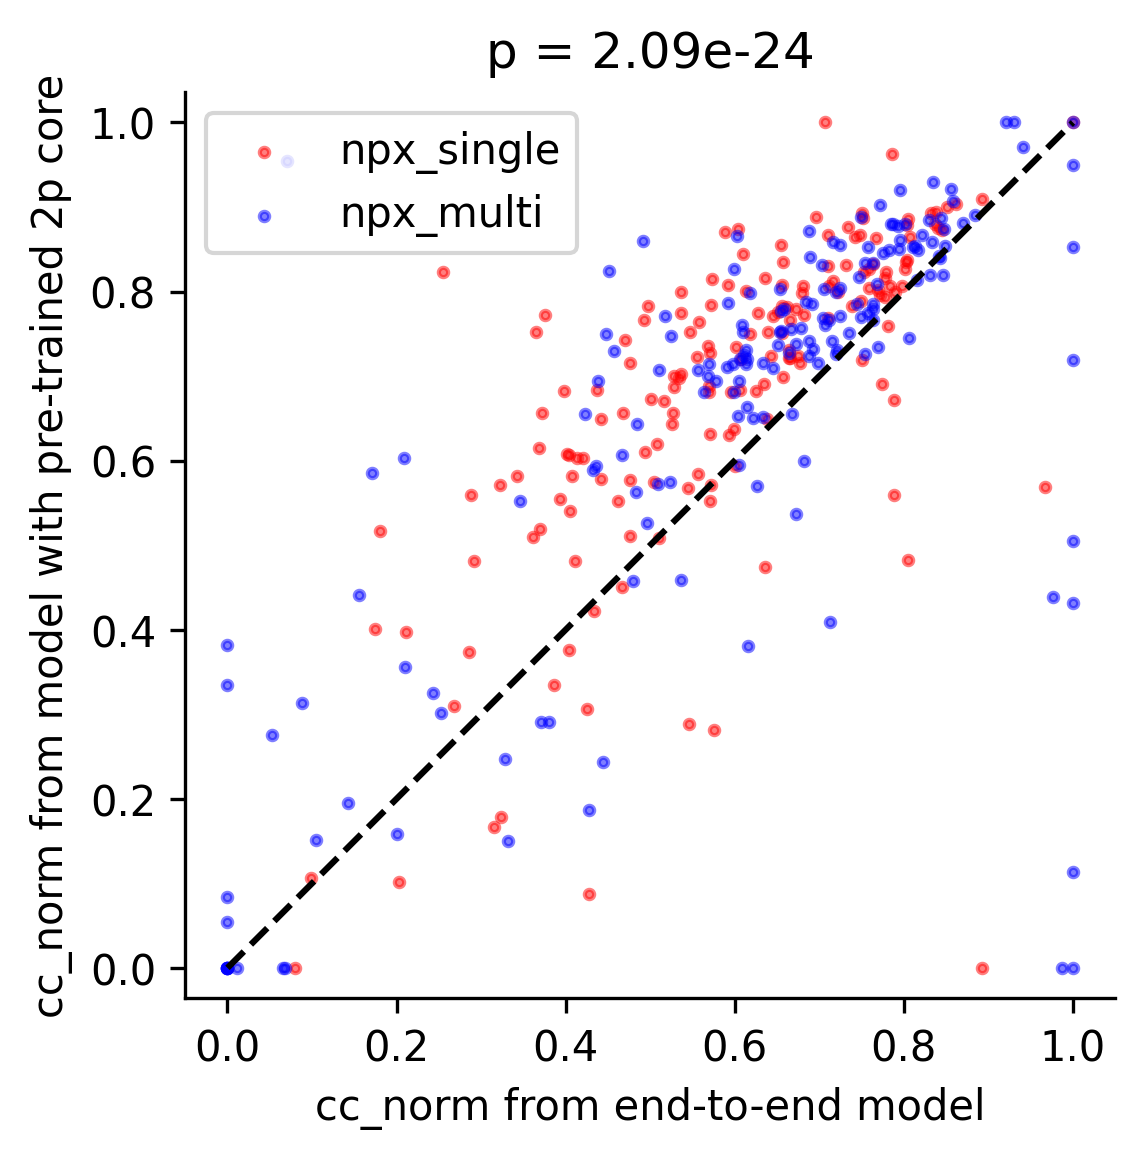

In [7]:
plt.figure(figsize=(4, 4), dpi=300)
plt.scatter(np.clip(cc_norm_e2e[npx_idxs][good_idx], 0, 1), np.clip(cc_norm_pretrain[npx_idxs][good_idx], 0, 1), c='r', label='npx_single', s=5, alpha=0.5)
plt.scatter(np.clip(cc_norm_e2e[npx_idxs][mua_idx], 0, 1), np.clip(cc_norm_pretrain[npx_idxs][mua_idx], 0, 1), c='b', label='npx_multi', s=5, alpha=0.5)
plt.xlabel('cc_norm from end-to-end model')
plt.ylabel('cc_norm from model with pre-trained 2p core')
plt.legend()
plt.plot([0, 1], [0, 1], c='k', linestyle='dashed')
p_wc = scipy.stats.wilcoxon(cc_norm_e2e[npx_idxs], cc_norm_pretrain[npx_idxs])[-1]
plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)))
plt.axis('equal')
sns.despine()
# plt.savefig('/src/notebooks/Figures/DEI rebuttal/supplement/[neuropixel]Comparison_of_cc_norm_between_end2end_and_pretrained.pdf', transparent=True)

# Compare 2p and npx diversity and bipartiteness

In [75]:
## get median functional thresholds used for 2p analysis, and apply for npx analysis

In [3]:
groups = [233, 237, 239, 243, 271, 272, 275, 279, 284, 285, 329, 330, 336, 337]
net_hash = ["8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da"]
data_hash = ["7572eed73113c993e7d1b92f83e270b4"]
ora_thre, corr_thre = [], []
for GROUP in groups:
    rel = base.UnitRanking.Unit & dict(group_id=GROUP, ranking_params=4) & [{'net_hash': i} for i in net_hash] & [{'data_hash': i} for i in data_hash]
    oracle, corr = (base.EnsembleEval.Unit * rel & 'ssid = 1').fetch('oracle_score', 'unit_avg_corr')
    ora_thre.append(np.percentile(oracle, 100 - np.sqrt(0.75)*100))
    corr_thre.append(np.percentile(corr, 100 - np.sqrt(0.75)*100))
ora_thre, corr_thre = np.median(ora_thre), np.median(corr_thre)
print(ora_thre, corr_thre)

0.22309754471642956 0.4174500463948931


### neuropixel metrics

In [6]:
## neuropixel data

# net_hash = 'net_hash = "8b6fe18fa651ebf452db0fbd77d05a01"'   # original model
net_hash = 'net_hash = "ebc0a36a504206eb9ed5a336e5b8a2b1"'   # pretrained 2p core model
# net_hash = 'net_hash = "e67196e0d324cc4a34b5e731dab1e0ed"'   # sensorium model

## apply functional thresholds
# neuron = (base.Dataset.Unit * base.NewEnsembleEval.Unit & 'group_id = 366' & 'cc_max > 0.4 and cc_abs > 0.2' & net_hash & deis_schema.Texture)
neuron = (base.Dataset.Unit * base.EnsembleEval.Unit & 'group_id = 366' & 'oracle_score > {} and unit_avg_corr > {}'.format(ora_thre, corr_thre) & net_hash)
neuron_dic = np.array(neuron.fetch(as_dict=True, order_by='animal_id, session, scan_idx, unit_id'))
label = np.array([(ephys.CuratedClustering.Unit * ephys.Session & dic).fetch1('cluster_quality_label') for dic in neuron_dic])
good_idx = np.where(label == 'good')[0]
mua_idx = np.where(label == 'mua')[0]

## fetch properties
keys, animals, sessions, scans, units, meis, masks, deis, sims, samples, vsizes, textures, mvs = \
((deis_schema.DEI & deis_schema.DEIGoodRun) * \
(deis_schema.Texture & deis_schema.TextureGoodRun) * \
base.MEI * base.MEIMask * neuron).fetch(dj.key, 'animal_id', 'session', 'scan_idx', 'unit_id', 'mei', 'mask', 'deis', 'avg_sim', 'samples', 'p', 'centered_texture', 'variable_mask', order_by='animal_id, session, scan_idx, unit_id')
sizes = np.stack(masks).sum(axis=(-1, -2))

## auc
ps, acts = \
((deis_schema.DEI & deis_schema.DEIGoodRun) * \
(deis_schema.Texture) * \
base.MEI * base.MEIMask * neuron).fetch('p', 'sample_avg_activation_ratio', order_by='animal_id, session, scan_idx, unit_id, texture_id')
ps = ps.reshape(-1, 10)
acts = acts.reshape(-1, 10)
auc_npx = []
for p, act in zip(ps, acts):
    fitted_p, fitted_act = deis_schema.spline_fit(p, act, processed=False, mode='spline')
    auc_npx.append(deis_schema.auc_cal(fitted_p, fitted_act))
    

### 2p metrics

In [4]:
## 2p data
rest1 = {'seed': 1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 14, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}
rest2 = {'seed': 1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}
rel1 = base.MEIMask * deis_schema.DEI * deis_schema.DEIGoodRun * deis_schema.Texture * deis_schema.TextureGoodRun & (deis_schema.NeuronSetRequest & 'method_id = 3') & rest1 & 'group_id in (233, 237)'
rel2 = base.MEIMask * deis_schema.DEI * deis_schema.DEIGoodRun * deis_schema.Texture * deis_schema.TextureGoodRun & (deis_schema.NeuronSetRequest & 'method_id = 3') & rest2 & 'group_id not in (233, 237)'
rel = rel1.proj() + rel2.proj()

# masks_2p, sims_2p, ps_2p = ((base.NewEnsembleEval.Unit & 'ssid = 1' & 'cc_max > 0.4 and cc_abs > 0.2') * \
#                             base.MEIMask * deis_schema.DEI * deis_schema.Texture & rel
#                            ).fetch('mask', 'avg_sim', 'p', order_by='group_id, neuron_id')

masks_2p, sims_2p, vsizes_2p = ((base.EnsembleEval.Unit & 'ssid = 1' & 'oracle_score > {} and unit_avg_corr > {}'.format(ora_thre, corr_thre)) * \
                            base.MEIMask * deis_schema.DEI * deis_schema.Texture & rel
                           ).fetch('mask', 'avg_sim', 'p', order_by='group_id, neuron_id')
sizes_2p = np.stack(masks_2p).sum(axis=(-1, -2))

# AUC
rest1 = {'seed': 1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 14, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}
rest2 = {'seed': 1009, 'mei_params':10, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 17, 'threshold_params': 2, 'texture_params': 20,  'score_params': 2}
rel1 = base.MEIMask * deis_schema.DEI * deis_schema.DEIGoodRun * deis_schema.Texture & (deis_schema.NeuronSetRequest & 'method_id = 3') & rest1 & 'group_id in (233, 237)'
rel2 = base.MEIMask * deis_schema.DEI * deis_schema.DEIGoodRun * deis_schema.Texture & (deis_schema.NeuronSetRequest & 'method_id = 3') & rest2 & 'group_id not in (233, 237)'
rel = rel1.proj() + rel2.proj()

ps, acts = \
((base.EnsembleEval.Unit & 'ssid = 1' & 'oracle_score > {} and unit_avg_corr > {}'.format(ora_thre, corr_thre)) * \
 base.MEIMask * deis_schema.DEI * deis_schema.Texture & rel
).fetch('p', 'sample_avg_activation_ratio', order_by='group_id, neuron_id, texture_id')
ps = ps.reshape(-1, 10)
acts = acts.reshape(-1, 10)
auc_2p = []
for p, act in zip(ps, acts):
    fitted_p, fitted_act = deis_schema.spline_fit(p, act, processed=False, mode='spline')
    auc_2p.append(deis_schema.auc_cal(fitted_p, fitted_act))

#### diversity index: mua vs single, mua vs 2p, single vs 2p

In [37]:
scipy.stats.ttest_ind(-sims[mua_idx], -sims[good_idx])

Ttest_indResult(statistic=8.623599342944246, pvalue=9.26448860667063e-16)

In [38]:
cal_dof(-sims[mua_idx], -sims[good_idx])

230.30067188594222

In [39]:
scipy.stats.ttest_ind(-sims[mua_idx], -sims_2p)

Ttest_indResult(statistic=13.22973870343454, pvalue=1.6651829899410528e-37)

In [40]:
cal_dof(-sims[mua_idx], -sims_2p)

122.60278349392904

In [41]:
scipy.stats.ttest_ind(-sims[good_idx], -sims_2p)

Ttest_indResult(statistic=1.2415036663588677, pvalue=0.21464613708139704)

In [42]:
cal_dof(-sims[good_idx], -sims_2p)

158.42807354924204

#### auc: mua vs single, mua vs 2p, single vs 2p

In [46]:
scipy.stats.ttest_ind(np.array(auc_npx)[good_idx], np.array(auc_npx)[mua_idx])

Ttest_indResult(statistic=-10.312045691268445, pvalue=7.512564891551637e-21)

In [47]:
cal_dof(np.array(auc_npx)[good_idx], np.array(auc_npx)[mua_idx])

237.75944694617755

In [48]:
scipy.stats.ttest_ind(auc_2p, np.array(auc_npx)[mua_idx])

Ttest_indResult(statistic=-9.973139330754156, pvalue=1.3439983658685899e-22)

In [49]:
cal_dof(np.array(auc_2p), np.array(auc_npx)[mua_idx])

129.51431177993723

In [11]:
scipy.stats.ttest_ind(auc_2p, np.array(auc_npx)[good_idx])

Ttest_indResult(statistic=4.708911712451416, pvalue=2.7603543444604004e-06)

In [8]:
def get_CI(x,ci=95):
    return np.percentile(x,(100-ci)/2),np.percentile(x,100-(100-ci)/2)

In [14]:
print(np.array(auc_2p).mean(),np.array(auc_2p).std())
print(np.array(auc_npx)[good_idx].mean(),np.array(auc_npx)[good_idx].std())
print(np.array(auc_npx)[mua_idx].mean(),np.array(auc_npx)[mua_idx].std())

0.6542823909398131 0.08396162589639734
0.6174090575729113 0.09969982616964528
0.7387090681467533 0.07629493089737958


In [24]:
print(diversity[:len(sims_2p)].mean(),diversity[:len(sims_2p)].std())
print(diversity[len(sims_2p):len(sims_2p)+len(good_idx)].mean(),diversity[len(sims_2p):len(sims_2p)+len(good_idx)].std())
print(diversity[-len(mua_idx):].mean(),diversity[-len(mua_idx):].std())

0.5135181290881646 0.2745985747197282
0.5450787193066924 0.30858647029916125
0.884612142422398 0.29260261295677786


In [51]:
cal_dof(np.array(auc_2p), np.array(auc_npx)[good_idx])

155.68570274693258

In [18]:
labels = ['Two-photon'] * len(sizes_2p) + ['Neuropixel_single'] * len(good_idx) + ['Neuropixel_multi'] * len(mua_idx)
mask_size = np.concatenate([sizes_2p, sizes[good_idx], sizes[mua_idx]])
diversity = deis_schema.convert_score(np.concatenate([-sims_2p, -sims[good_idx], -sims[mua_idx]]))
normalized_variable_subfield_size = np.concatenate([vsizes_2p, vsizes[good_idx], vsizes[mua_idx]])
AUC = np.concatenate([np.array(auc_2p), np.array(auc_npx)[good_idx], np.array(auc_npx)[mua_idx]])
df = pd.DataFrame(dict(label=labels, mask_size=mask_size, diversity=diversity, normalized_variable_subfield_size=normalized_variable_subfield_size, AUC=AUC))

In [23]:
diversity[:-2]

array([0.70137097, 0.43622581, 0.38251613, ..., 0.72582258, 1.24740323,
       1.29003226])

In [33]:
col_names = ['mask_size', 'diversity', 'normalized_variable_subfield_size', 'AUC']
ylabels = ['RF size', 'Diversity index', 'Normalized variable subfield size', 'Bipartiteness index']
xlabels = ['Two-photon', 'Npx single', 'Npx multi']

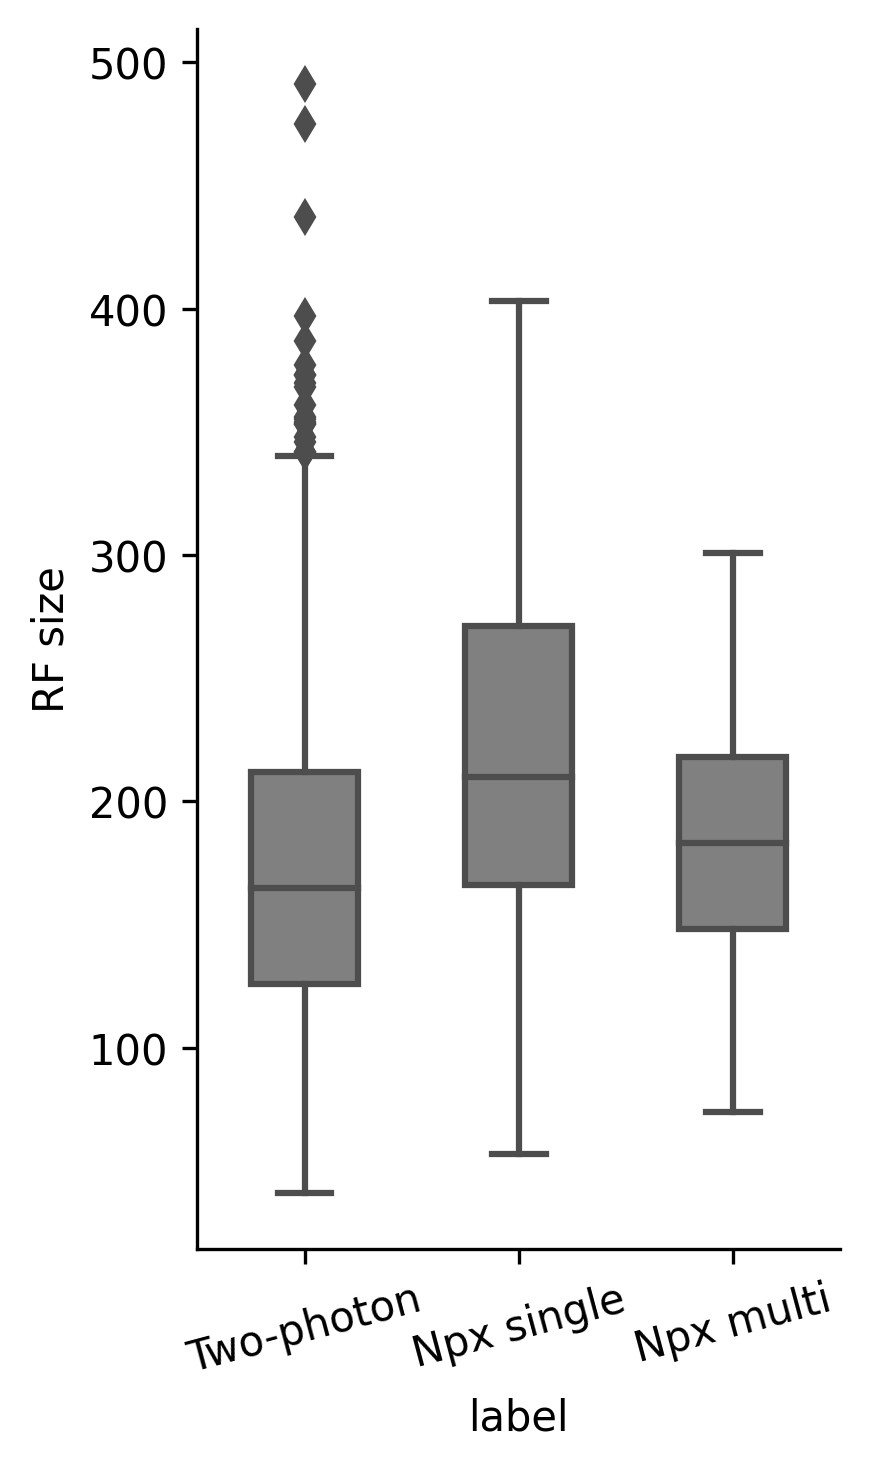

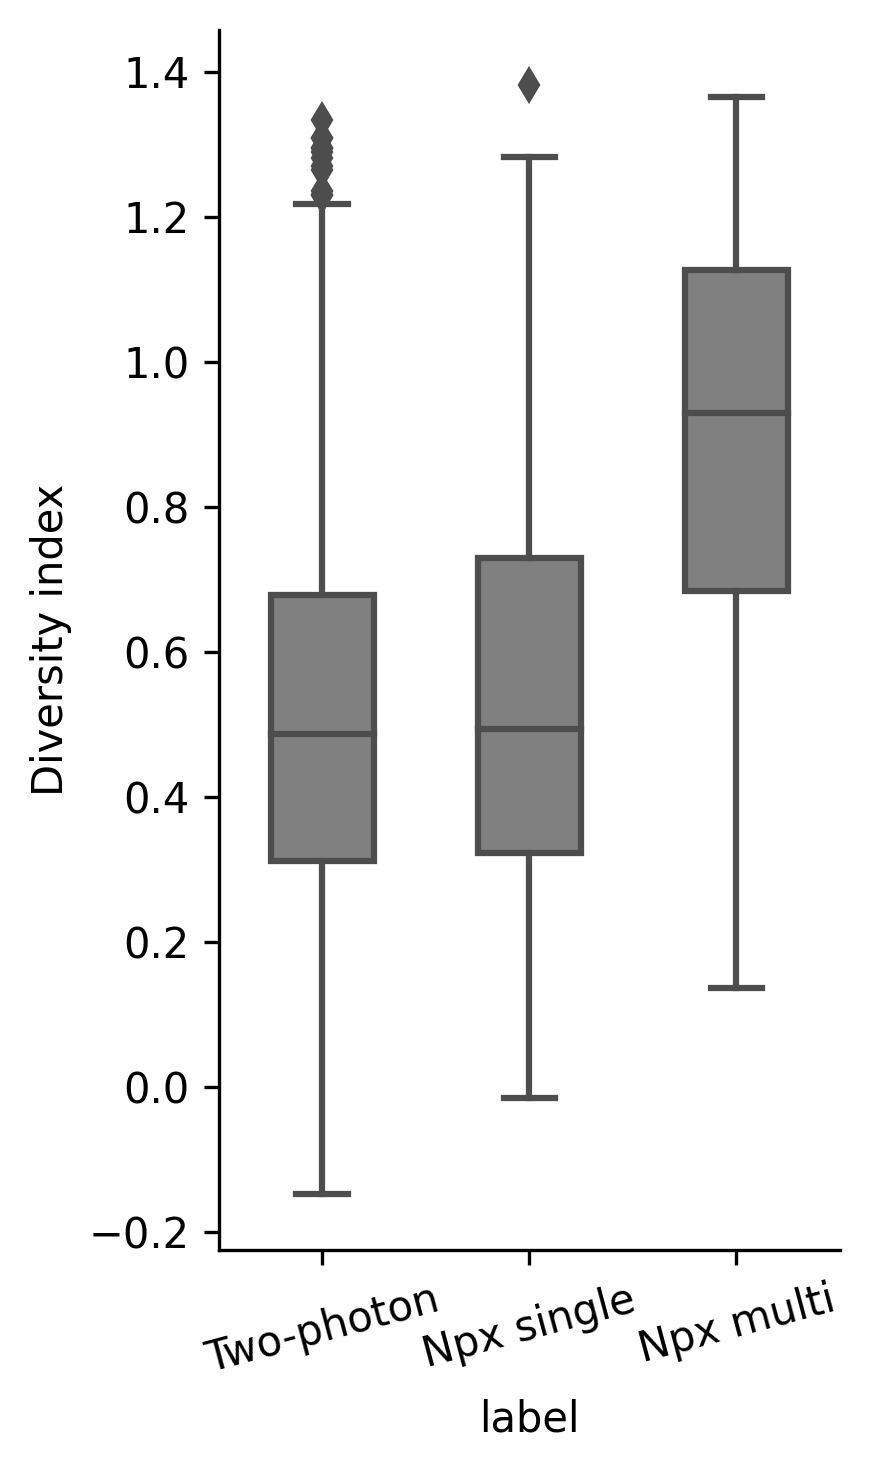

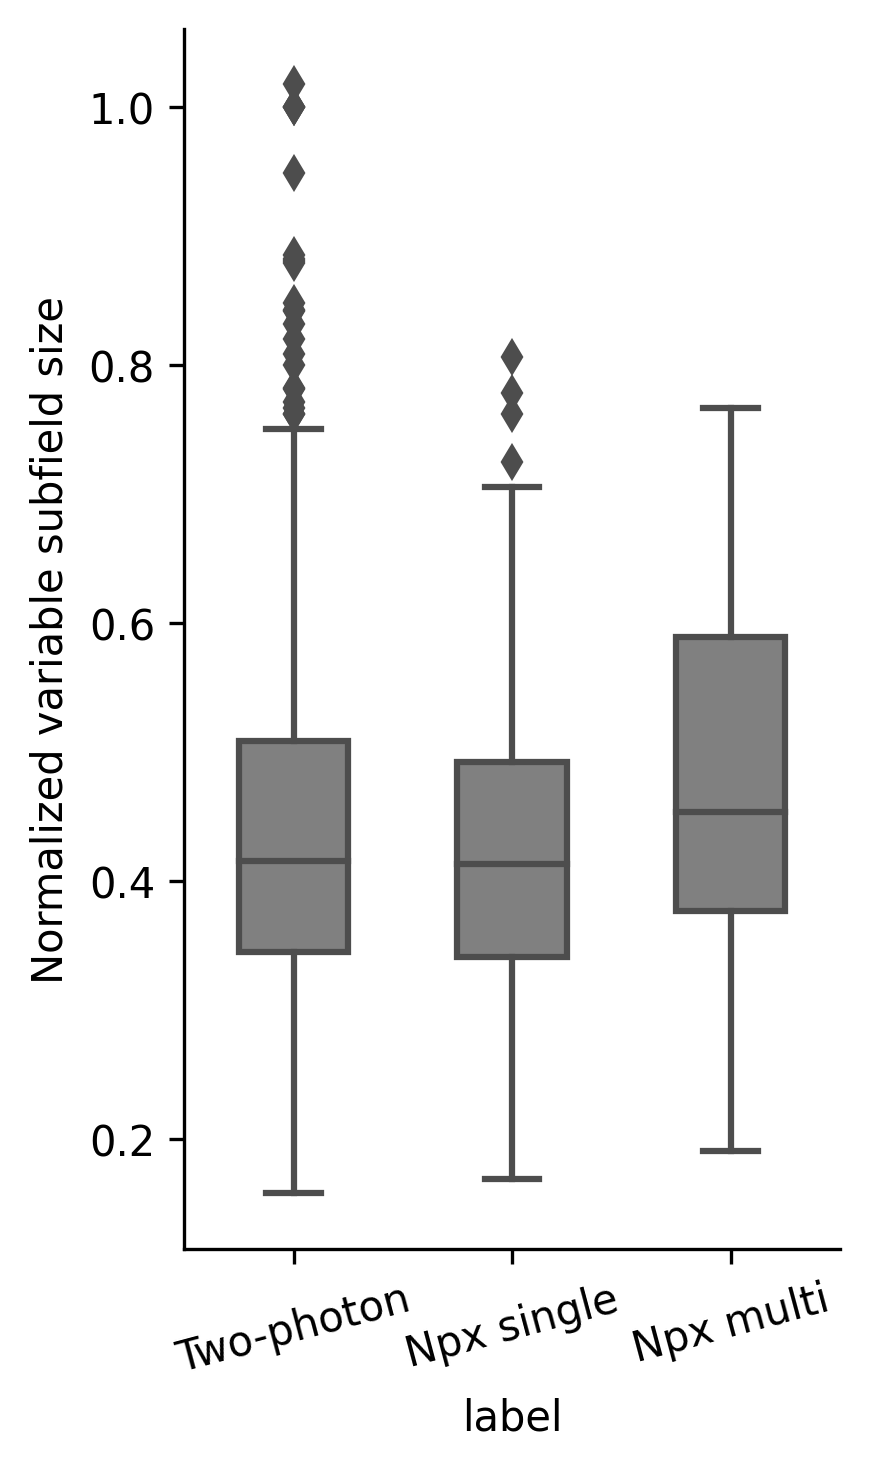

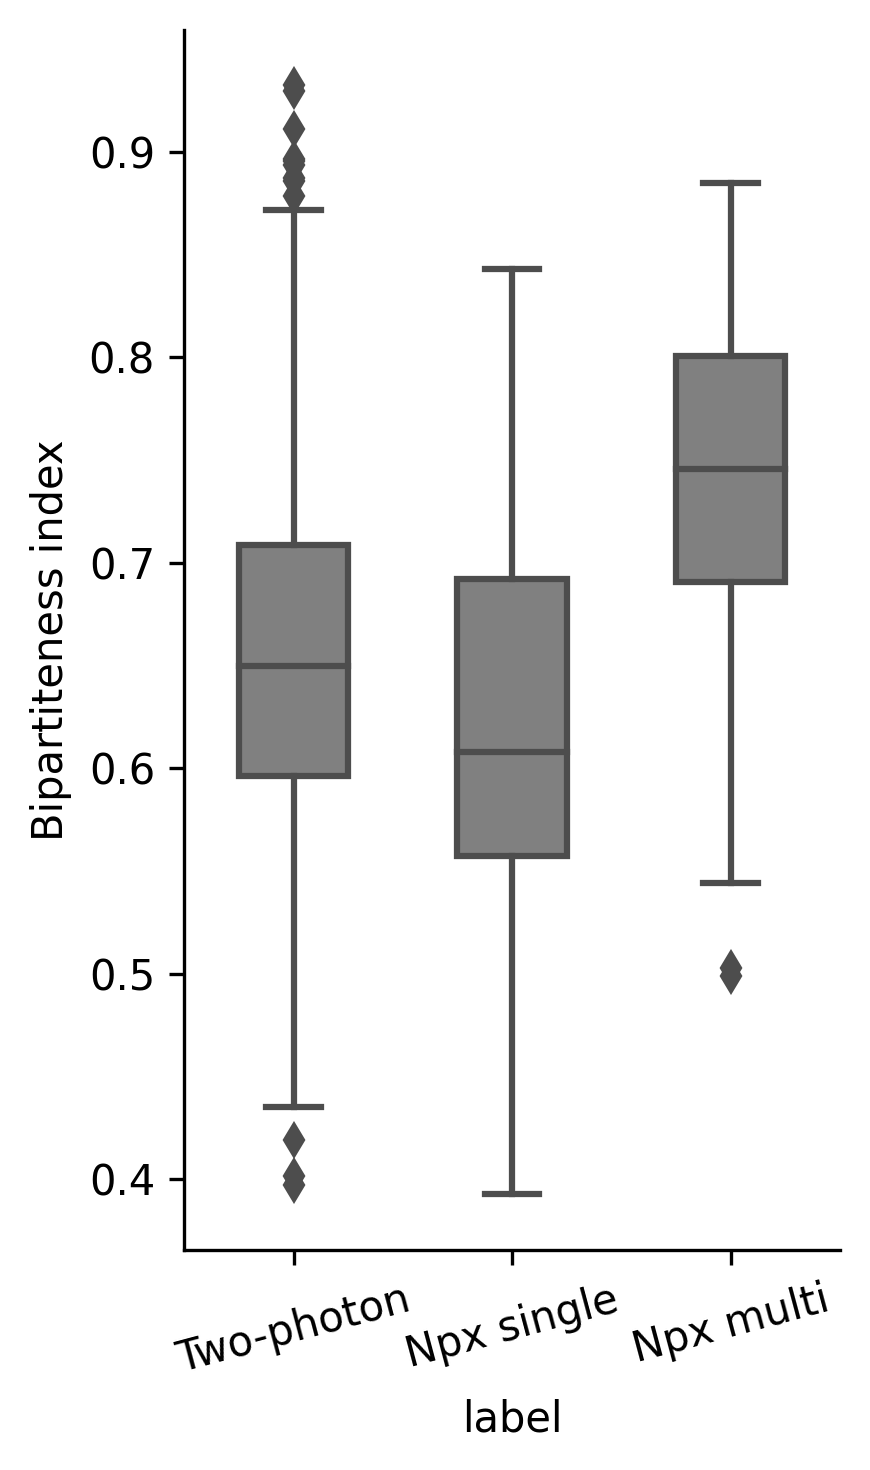

In [34]:
for col, yl in zip(col_names, ylabels):
    plt.figure(figsize=(3, 5), dpi=300)
    sns.boxplot(data=df, x="label", y=col, color='gray', width=0.5)
    sns.despine()
    plt.xticks(plt.gca().get_xticks(), xlabels)
    sns.despine()
    plt.xticks(rotation=15)
    plt.ylabel(yl)
    plt.tight_layout()
    plt.show()
    # plt.savefig('/src/notebooks/Figures/DEI rebuttal/supplement/[neuropixel]Comparison_of_{}.pdf'.format(yl), transparent=True)
    # plt.close()

#### converting MEI diameter to degree

In [26]:
# mask_df = dict()
# mask_df['2p'] = masks_2p
# mask_df['good'] = masks[good_idx]
# mask_df['mua'] = masks[mua_idx]

# import pickle
# with open('/src/notebooks/DEI rebuttal/neuropixel_mei_masks.pickle','wb') as handle:
#     pickle.dump(mask_df,handle)

import pickle
with open('/src/notebooks/DEI rebuttal/neuropixel_mei_masks.pickle', "rb") as f:
    mask_df = pickle.load(f)

In [27]:
def get_boundary(label,parameters={'method':'8-connected'}):
    from scipy.ndimage import binary_erosion
    if parameters['method'] == '8-connected':
        k = np.zeros((3,3),dtype=int); k[1] = 1; k[:,1] = 1
    else:
        k = np.ones((3,3),dtype=int)
    boundary = label-binary_erosion(label,k)
    return boundary

def find_diameter_of_mask(mask,threshold=0.3, deg_per_px=1.94):
    from scipy.ndimage import binary_erosion
    from scipy.spatial import distance_matrix
    boundary = get_boundary((mask>threshold).astype(np.float)).astype(np.float)
    boundary_points = np.argwhere(boundary)
    dist_matrix = distance_matrix(boundary_points, boundary_points)
    diameter = np.max(dist_matrix)
    return diameter * deg_per_px

In [ ]:
31.8cm 1080px 2.2degree/cm 36px

In [ ]:
31.8*2.2 / 36

1.9433333333333336

In [32]:
print(d_2p.mean(),d_2p.std())
print(d_single.mean(),d_single.std())
print(d_mua.mean(),d_mua.std())

34.894967181665 6.644679206026993
38.783271705726385 6.362279229476893
35.57902800046838 4.990545451188498


In [28]:
## convert MEI diameter to degree
d_2p = np.array([find_diameter_of_mask(mask) for mask in mask_df['2p']])
d_single = np.array([find_diameter_of_mask(mask) for mask in mask_df['good']])
d_mua = np.array([find_diameter_of_mask(mask) for mask in mask_df['mua']])

/tmp/ipykernel_273/2638372334.py:13: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  boundary = get_boundary((mask>threshold).astype(np.float)).astype(np.float)


In [29]:
labels = ['Two-photon'] * len(d_2p) + ['Neuropixel_single'] * len(d_single) + ['Neuropixel_multi'] * len(d_mua)
mei_diameter = np.concatenate([d_2p, d_single, d_mua])
df = pd.DataFrame(dict(label=labels, mei_diameter=mei_diameter))

In [30]:
col_names = ['mei_diameter']
ylabels = ['MEI diameter ($^\circ$)']
xlabels = ['2p', 'Neuropixel\nsingle unit', 'Neuropixel\nmulti unit']

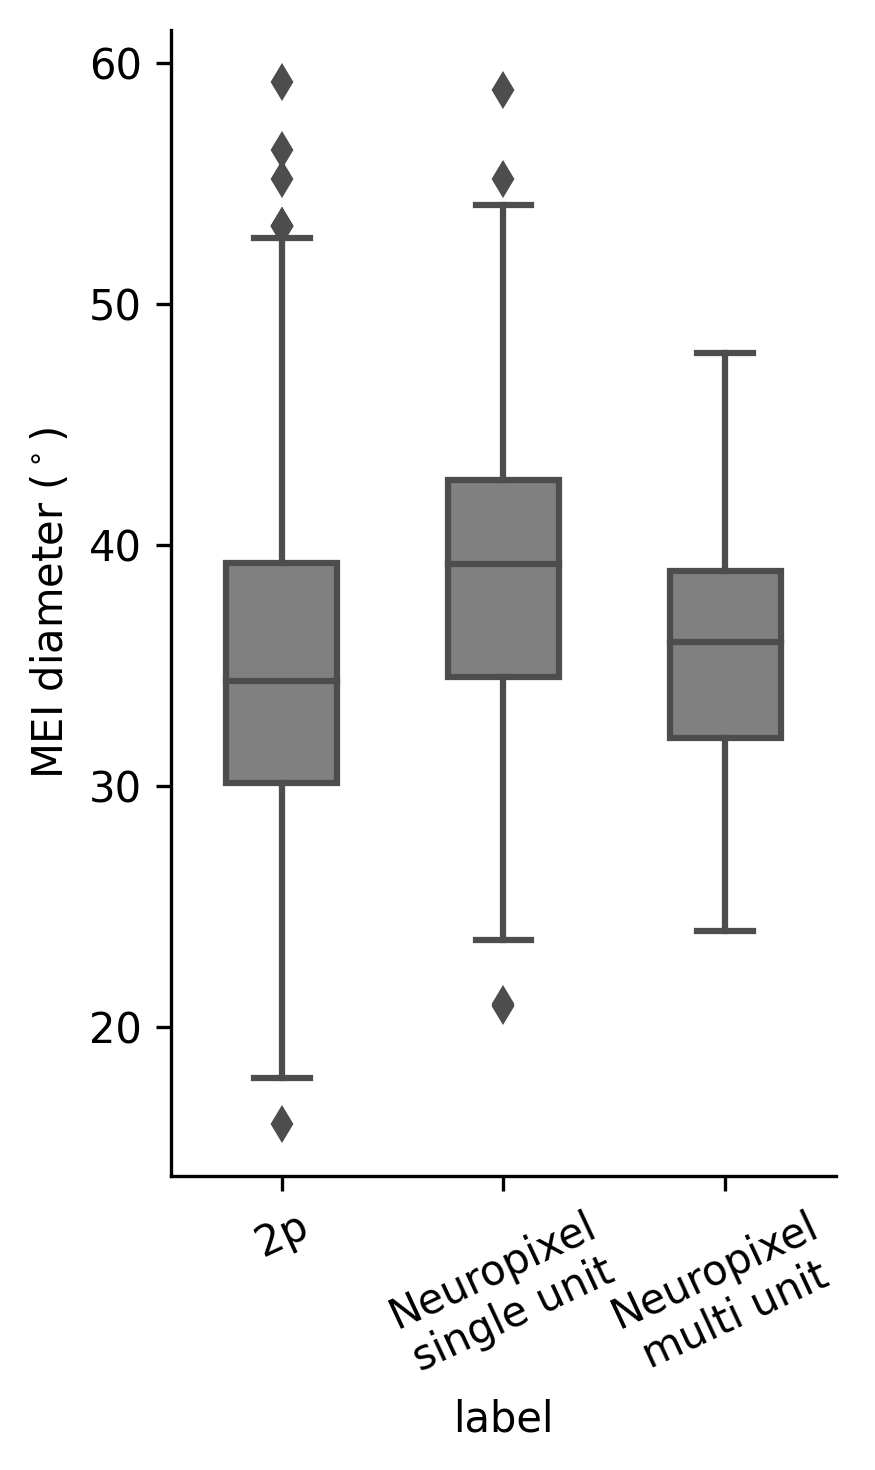

In [31]:
for col, yl in zip(col_names, ylabels):
    plt.figure(figsize=(3, 5), dpi=300)
    sns.boxplot(data=df, x="label", y=col, color='gray', width=0.5)
    sns.despine()
    plt.xticks(plt.gca().get_xticks(), xlabels)
    sns.despine()
    plt.xticks(rotation=25)
    plt.ylabel(yl)
    plt.tight_layout()
    # plt.savefig('/src/notebooks/Figures/DEI rebuttal/supplement/[neuropixel]Comparison_of_{}.pdf'.format(yl), transparent=True)
    # plt.close()

In [25]:
def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))

In [52]:
scipy.stats.ttest_ind(d_single, d_mua)

Ttest_indResult(statistic=4.234822850719947, pvalue=3.2698734190770345e-05)

In [53]:
cal_dof(d_single, d_mua)

237.98700864113093

In [23]:
scipy.stats.ttest_ind(d_2p, d_single)

Ttest_indResult(statistic=-6.434781856595156, pvalue=1.7406992583571365e-10)

In [27]:
cal_dof(d_2p, d_single)

168.5118670566688

In [28]:
scipy.stats.ttest_ind(d_2p, d_mua)

Ttest_indResult(statistic=-1.0326643426314466, pvalue=0.30195948694035313)

In [29]:
cal_dof(d_2p, d_mua)

141.63783046313318